# Fashion-MNIST classifier

In [25]:
import sys
sys.path.append('..')

from src.utils import load_fashion_mnist, plot_examples, train_val_split
from src.model import NeuralNetwork

## Load and inspect the data

In [26]:
x_train, x_test, y_train, y_test = load_fashion_mnist()
x_train, x_val, y_train, y_val = train_val_split(x_train, y_train)
print(x_train.shape, x_test.shape)

(784, 50000) (784, 10000)


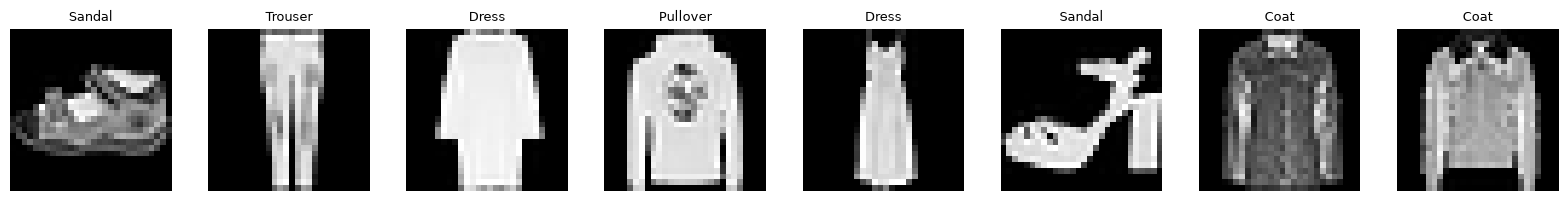

In [27]:
plot_examples(x_train, y_train)

## Train

In [28]:
model = NeuralNetwork(layer_dims=[784, 64, 32, 10])
train_costs, val_costs = model.train(
    x_train, y_train, x_val, y_val, patience=3, n_classes=10,
    epochs=30, batch_size=64, learning_rate=0.1
)

Epoch 0: cost = 0.6394
Epoch 5: cost = 0.3412


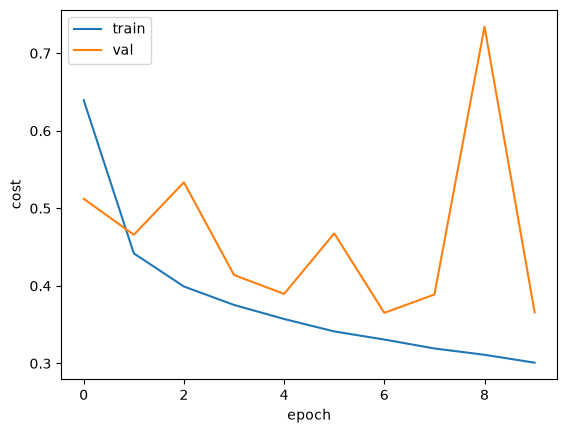

In [29]:
import matplotlib.pyplot as plt

plt.plot(train_costs, label='train')
plt.plot(val_costs, label='val')
plt.xlabel('epoch')
plt.ylabel('cost')
plt.legend()
plt.show()

## Evaluate

In [30]:
preds = model.predict(x_test)
accuracy = (preds == y_test).mean()
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.8605


## Error Analysis

In [54]:
from src.metrics import confusion_matrix, precision_recall
from src.utils import CLASS_NAMES

cm = confusion_matrix(y_test, preds, n_classes=10)
precision, recall = precision_recall(y_test, preds, n_classes=10)

# normalize the confusion matrix
norm_cm = cm / cm.sum(axis=1, keepdims=True)

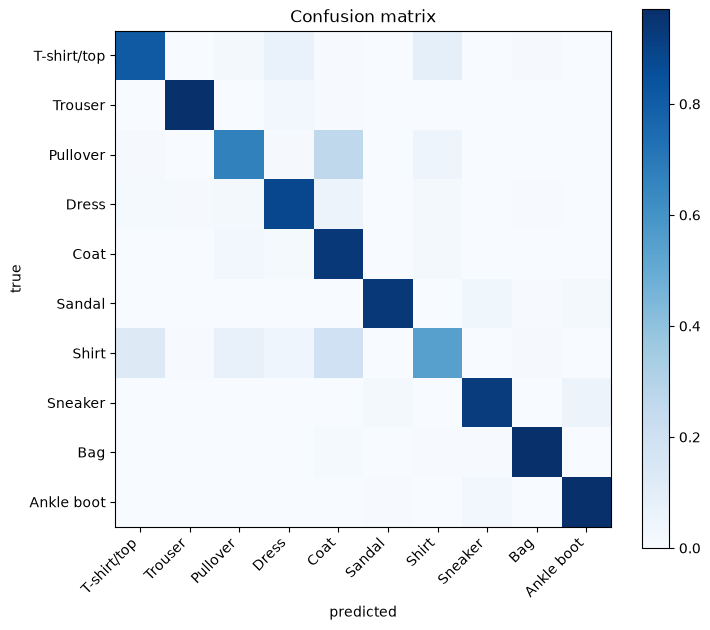

In [55]:
plt.figure(figsize=(8, 7))     # new canvas, 8×7 inches
plt.imshow(norm_cm, cmap='Blues')   # paint the 10×10 array as a grid of colored squares
plt.colorbar()                 # the strip showing what each color means
plt.xticks(range(10), CLASS_NAMES, rotation=45, ha='right')
plt.yticks(range(10), CLASS_NAMES)
plt.xlabel('predicted')
plt.ylabel('true')
plt.title('Confusion matrix')
plt.show()                     # render it

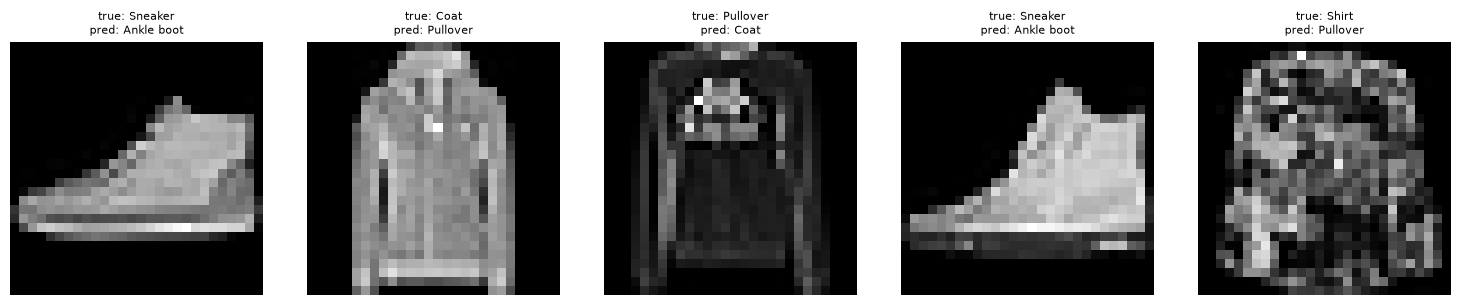

In [48]:
import numpy as np

misclassified = np.where(preds != y_test)[0]   # indices where prediction was wrong
some_indices = misclassified[:5]               # show the first 5

fig, axes = plt.subplots(1, 5, figsize=(15, 3))   # 1 row, 5 columns of mini-canvases
for ax, idx in zip(axes, some_indices):
    ax.imshow(x_test[:, idx].reshape(28, 28), cmap='gray')   # draw on THIS mini-plot
    ax.set_title(f"true: {CLASS_NAMES[y_test[idx]]}\npred: {CLASS_NAMES[preds[idx]]}", fontsize=8)
    ax.axis('off')             # hide the tick marks
plt.tight_layout()             # auto-space so titles don't overlap
plt.show()

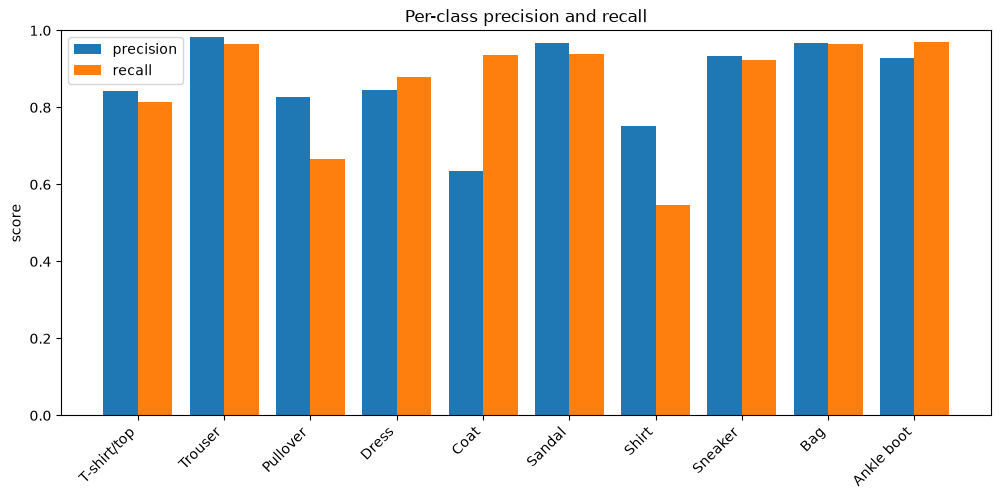

In [58]:
x = np.arange(10)        # a slot position for each class
width = 0.4              # how wide each bar is

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, precision, width, label='precision')
plt.bar(x + width/2, recall,    width, label='recall')
plt.xticks(x, CLASS_NAMES, rotation=45, ha='right')
plt.ylabel('score')
plt.ylim(0, 1)           # both are fractions, so a 0..1 axis
plt.legend()             # shows which color is which
plt.title('Per-class precision and recall')
plt.show()